In [ ]:
import numpy as np
import pandas as pd

# Constants
contractor_aov = 16849
N = 100  # Number of contractor-influenced transactions per cycle
attrition_rates = np.arange(0, 1.1, 0.1)  # From 0% to 100% attrition

revenue_loss = []
for rate in attrition_rates:
    lost_transactions = int(N * rate)
    lost_revenue = lost_transactions * contractor_aov
    revenue_loss.append((f"{int(rate*100)}%", lost_revenue))

df_attrition = pd.DataFrame(revenue_loss, columns=["Attrition Rate", "Estimated Revenue Loss (₹)"])
print(df_attrition)


   Attrition Rate  Estimated Revenue Loss (₹)
0              0%                           0
1             10%                      168490
2             20%                      336980
3             30%                      505470
4             40%                      673960
5             50%                      842450
6             60%                     1010940
7             70%                     1179430
8             80%                     1347920
9             90%                     1516410
10           100%                     1684900


In [ ]:
contractor_revenue = 13_50_000  # e.g. from simulation
commission_rates = [0.09, 0.10, 0.11, 0.12, 0.13, 0.14]

for rate in commission_rates:
    payout = contractor_revenue * rate
    print(f"At {int(rate*100)}% commission, contractor payout = ₹{payout:,.0f}")


At 9% commission, contractor payout = ₹121,500
At 10% commission, contractor payout = ₹135,000
At 11% commission, contractor payout = ₹148,500
At 12% commission, contractor payout = ₹162,000
At 13% commission, contractor payout = ₹175,500
At 14% commission, contractor payout = ₹189,000


In [ ]:
lost_volume = 80
organic_rate_per_month = 20
recovery_months = lost_volume / organic_rate_per_month
lost_revenue = lost_volume * 16004

print(f"Time to recover: {recovery_months:.1f} months")
print(f"Revenue loss until recovery: ₹{lost_revenue:,.0f}")


Time to recover: 4.0 months
Revenue loss until recovery: ₹1,280,320


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data
attrition_rates = np.arange(0, 1.1, 0.1)
revenue_loss = np.array([rate * contractor_aov * N for rate in attrition_rates])
commission_rate = 0.13  # or pick any one for overlay
commission_cost = contractor_revenue * commission_rate
recovery_months = lost_volume / organic_rate_per_month

# DataFrame for plotting
df_plot = pd.DataFrame({
    "Attrition %": [f"{int(r*100)}%" for r in attrition_rates],
    "Attrition Rate": attrition_rates,
    "Revenue Loss": revenue_loss
})


/tmp/ipython-input-6-3729964088.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Attrition %", y="Revenue Loss", data=df_plot, palette="Reds")


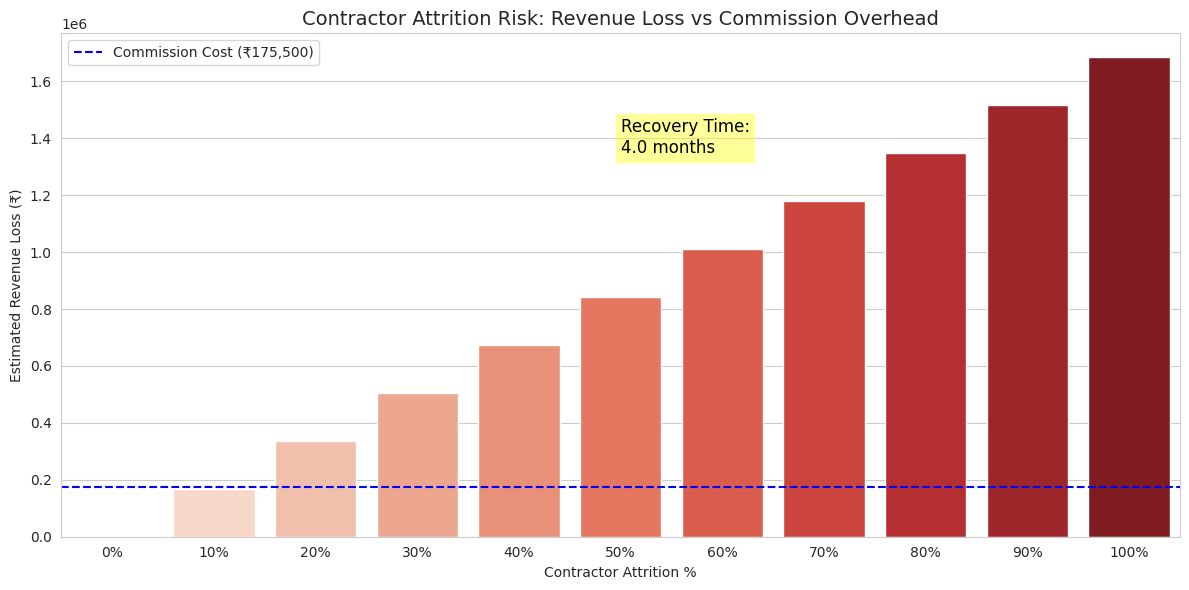

In [ ]:
# Plot setup
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Barplot for revenue loss
sns.barplot(x="Attrition %", y="Revenue Loss", data=df_plot, palette="Reds")

# Horizontal line for commission cost
plt.axhline(y=commission_cost, color='blue', linestyle='--', label=f'Commission Cost (₹{int(commission_cost):,})')

# Annotate recovery time
plt.text(5, max(revenue_loss)*0.8, f"Recovery Time:\n{recovery_months:.1f} months", fontsize=12, color="black", bbox=dict(facecolor='yellow', alpha=0.4))

# Titles & labels
plt.title("Contractor Attrition Risk: Revenue Loss vs Commission Overhead", fontsize=14)
plt.xlabel("Contractor Attrition %")
plt.ylabel("Estimated Revenue Loss (₹)")
plt.legend()
plt.tight_layout()
plt.show()
